In [1]:
import glob, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr


from rimeX.preproc.quantilemaps import make_quantilemap_prediction#, make_timesensitive_quantilemap_prediction
from rimeX.emulator import recombine_gmt_ensemble, load_magicc_ensemble

In [2]:
def make_timesensitive_quantilemap_prediction(quantile_maps, gmt, region, indicator, samples=100, seed=42, quantiles=[0.5, .05, .95], mode="deterministic", clip=False, skipna=False):
    """Make a prediction form the quantile map for a given global mean temperature using different quantile_maps per year. You can use this function to account for e.g. timesensitive weighting schemes in your emulation appearing when socioeconomic conditions change

    Parameters
    ----------
    quantile_maps : dictionary with all years as keys and paths to xr.DataArrays produced by make_quantile_map_array as values.

    gmt : pandas DataFrame for the global mean temperature, with years as index and ensemble members as columns

    region: string, region to make the prediction for

    indicator: string, indicator to make the prediction for

    samples : number of samples to draw (default: 100)

    seed : random seed

    quantiles : quantiles to compute (default: [0.5, .05, .95])
        if None, all ensemble members are returned

    mode : {"deterministic", "factorial", "montecarlo"}
        - "deterministic" (the default): gmt is resampled deterministically
        - "montecarlo" : gmt is simply resampled (may speed-up the computation at the cost of some loss of precision)
        - "factorial" : gmt is combined with the quantile map in a factorial way
            The total number of samples is then samples * gmt.shape[1]
        Note the impact distribution is always resampled in a deterministic way

    clip : bool
        if True, clip the GMT data to the range of the quantile map, otherwise fill with NaNs
        False by default

    skipna : bool
        if True, skip NaN values in the quantiles calculation (default: False)
        can be useful if clip is set to False

    Returns
    -------
    sampled_maps : xr.DataArray with dimensions year, sample
    """
    predictions = []
    
    for year, quantile_map_path in quantile_maps.items():
        
        relevant_gmt = gmt.loc[[year]]
        
        with xr.open_dataset(quantile_map_path) as ds:
            relevant_quantile_map = ds[indicator].sel(region=region).load()
        
        prediction = make_quantilemap_prediction(relevant_quantile_map, relevant_gmt, samples=samples, seed=seed, quantiles=quantiles, mode=mode, clip=clip, skipna=skipna)
        
        predictions.append(prediction)

    sampled_maps = xr.concat(predictions, dim = 'year')
    
    return sampled_maps

##### Function to load scenario data

In [3]:
PATH = '/Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/'
magicc_files = f'{PATH}NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv'
scenario = load_magicc_ensemble(file=magicc_files, projection_baseline=None,projection_baseline_offset=None).reindex(np.arange(1950,2100+1,1))
INDICATOR = 'HI-extreme-caution-QDM-v1'
COUNTRY = 'IND'
SEASON = 'annual'


weightings = {}
for i in range(150):
    if 1950+i <= 2025:
        weightings[1950+i] = f'historical_{1950+i}_popweight'
    else:
        weightings[1950+i] = f'ssp2_{1950+i}_popweight'

quantile_maps = {year: f'{PATH}isimip3/running-21-years/quantilemaps_regional_admin/{INDICATOR}/{COUNTRY}/{INDICATOR}_{SEASON}_{COUNTRY.lower()}_{weighting}_eq.nc' for year,weighting in weightings.items()}

prediction = make_timesensitive_quantilemap_prediction(quantile_maps, scenario, region = COUNTRY, indicator = INDICATOR, samples = 5000)

[10:31:16 | rimeX | INFO] Load MAGICC ensemble /Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None


FileNotFoundError: [Errno 2] No such file or directory: '/Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv'

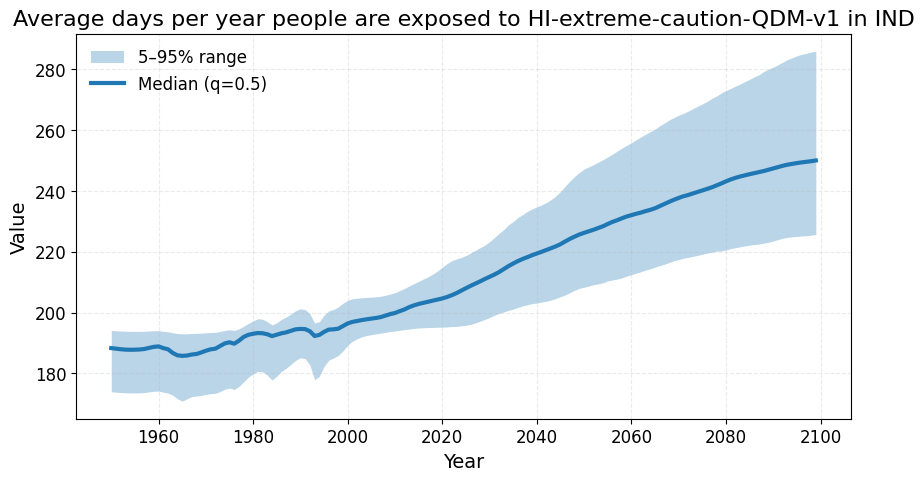

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_quantile_timeseries(
    da,
    central_quantile=0.5,
    lower_quantile=0.05,
    upper_quantile=0.95,
    ax=None,
    color=None,
    label=None,
    figsize=(10, 5),
    title=None,
):
    """
    Plot a time series with quantile uncertainty shading.

    Returns
    -------
    fig, ax
    """

    if color is None:
        color = sns.color_palette("tab10")[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    years = da["year"].values
    central = da.sel(quantile=central_quantile).values
    lower = da.sel(quantile=lower_quantile).values
    upper = da.sel(quantile=upper_quantile).values

    # Uncertainty band
    ax.fill_between(
        years,
        lower,
        upper,
        color=color,
        alpha=0.3,
        linewidth=0,
        label=f"{int(lower_quantile*100)}–{int(upper_quantile*100)}% range",
    )

    # Central line
    ax.plot(
        years,
        central,
        color=color,
        linewidth=3,
        label=label or f"Median (q={central_quantile})",
    )

    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel(da.name if da.name else "Value", fontsize=14)
    ax.set_title(title or da.name, fontsize=16)
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.tick_params(axis="both", labelsize=12)
    ax.legend(frameon=False, fontsize=12)

    return fig, ax

from pathlib import Path

PLOT_DIR = Path("climate-impact-explorer-preprocessing/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plot_quantile_timeseries(
    prediction,
    title=f"Average days per year people are exposed to {INDICATOR} in {COUNTRY}",
)

#outfile = PLOT_DIR / "regional_climate_impact.png"
#fig.savefig(outfile, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)



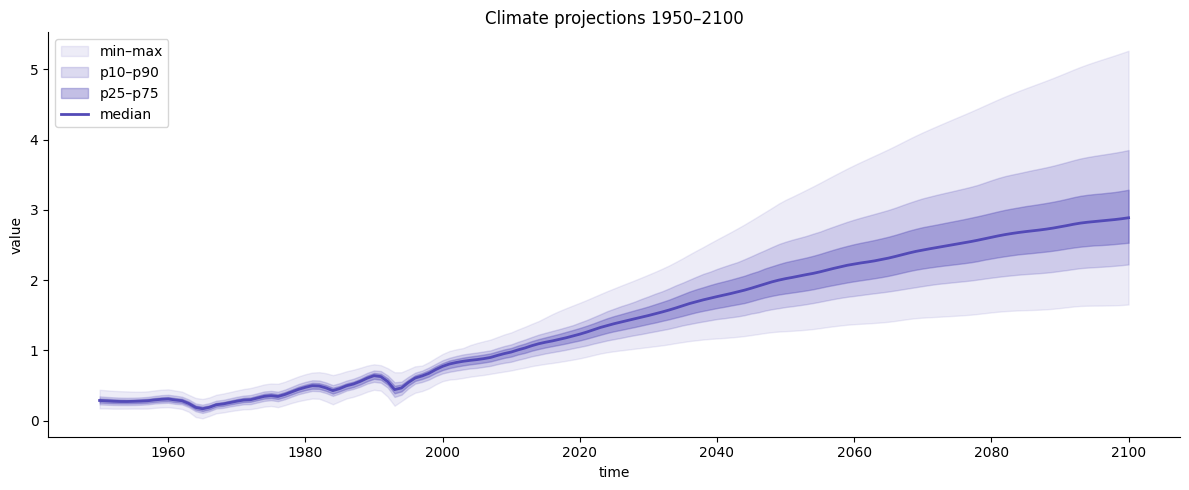

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ensemble(df, title="Ensemble forecast", figsize=(12, 5)):
    idx = df.index
    vals = df.values

    median = np.median(vals, axis=1)
    p10, p25, p75, p90 = np.percentile(vals, [10, 25, 75, 90], axis=1)
    mn, mx = vals.min(axis=1), vals.max(axis=1)

    color = "#534AB7"

    fig, ax = plt.subplots(figsize=figsize)

    ax.fill_between(idx, mn, mx, alpha=0.10, color=color, label="min–max")
    ax.fill_between(idx, p10, p90, alpha=0.20, color=color, label="p10–p90")
    ax.fill_between(idx, p25, p75, alpha=0.35, color=color, label="p25–p75")
    ax.plot(idx, median, color=color, linewidth=2, label="median")

    ax.set_title(title)
    ax.set_xlabel(df.index.name or "time")
    ax.set_ylabel("value")
    ax.legend(loc="upper left")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_ensemble(scenario, title="Climate projections 1950–2100")

### Save data - several indicators, one state, several scenarios

In [ ]:
#---- specify country, province/state, indicators, scenarios

PATH = '/Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/'
COUNTRY = 'IND'
indicators = ['HI-caution-QDM-v1', 'HI-extreme-caution-QDM-v1', 'HI-danger-QDM-v1', 'HI-extreme-danger-QDM-v1']
scenarios = {'NGFS CurPol': '/Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv', 
             'NGFS Net-Zero 2050': '/Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/NGFS_scenarios/o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv'}
SEASON = 'annual'

quantiles = [.5, 0.05, 0.1, 0.25, 0.75, 0.9, 0.95]


weightings = {}
for i in range(150):
    if 1950+i <= 2025:
        weightings[1950+i] = f'historical_{1950+i}_popweight'
    else:
        weightings[1950+i] = f'ssp2_{1950+i}_popweight'


all_data = xr.Dataset()

#---- loop over all selected countries
for INDICATOR in indicators:

    quantile_maps = {year: f'{PATH}isimip3/running-21-years/quantilemaps_regional_admin/{INDICATOR}/{COUNTRY}/{INDICATOR}_{SEASON}_{COUNTRY.lower()}_{weighting}_eq.nc' for year,weighting in weightings.items()}

    
    #---- generate RIME-X predictions but with time-evolving population-weighted data for all scenarios
    for scen_index, SCEN in enumerate(scenarios):

        scenario = load_magicc_ensemble(file=scenarios[SCEN], projection_baseline=None,projection_baseline_offset=None).reindex(np.arange(1950,2100+1,1))
        
        prediction = make_timesensitive_quantilemap_prediction(quantile_maps, scenario, region = COUNTRY, indicator = INDICATOR, samples = 5000, quantiles = quantiles)
        all_data[INDICATOR, SCEN] = prediction

all_data

[16:44:39 | rimeX | INFO] Load MAGICC ensemble /Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None
[16:44:39 | rimeX | INFO] Load MAGICC ensemble /Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/NGFS_scenarios/o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None
[16:44:40 | rimeX | INFO] Load MAGICC ensemble /Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/NGFS_scenarios/h_cpol_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None
[16:44:40 | rimeX | INFO] Load MAGICC ensemble /Users/quentinlejeune/Documents/VUB/Lifetime_Exposure/For_RIMEX_260323/NGFS_scenarios/o_1p5c_REMIND-MAgPIE-3.3-4.7_MAGICC_out_formatted_final.csv with baseline None and offset None
[16:44:41 | rimeX | INFO] Load MAGICC ensemble /Users/quentinlejeune/Documents/VUB/Lifet

<xarray.Dataset> Size: 68kB
Dimensions:                                              (quantile: 7, year: 150)
Coordinates:
  * quantile                                             (quantile) float64 56B ...
  * year                                                 (year) int64 1kB 195...
Data variables:
    ('HI-caution-QDM-v1', 'NGFS CurPol')                 (quantile, year) float64 8kB ...
    ('HI-caution-QDM-v1', 'NGFS Net-Zero 2050')          (quantile, year) float64 8kB ...
    ('HI-extreme-caution-QDM-v1', 'NGFS CurPol')         (quantile, year) float64 8kB ...
    ('HI-extreme-caution-QDM-v1', 'NGFS Net-Zero 2050')  (quantile, year) float64 8kB ...
    ('HI-danger-QDM-v1', 'NGFS CurPol')                  (quantile, year) float64 8kB ...
    ('HI-danger-QDM-v1', 'NGFS Net-Zero 2050')           (quantile, year) float64 8kB ...
    ('HI-extreme-danger-QDM-v1', 'NGFS CurPol')          (quantile, year) float64 8kB ...
    ('HI-extreme-danger-QDM-v1', 'NGFS Net-Zero 2050')   (quantile, year) float64 8kB ...

##### Convert xarray dataset to dataframe and adjust format

In [ ]:
#---- convert to dataframe
all_data_df = all_data.to_dataframe().reset_index()
all_data_df 

quantile  year HI-caution-QDM-v1                     \
                          NGFS CurPol NGFS Net-Zero 2050   
0        0.50  1950        295.211885         295.211885   
1        0.50  1951        295.167465         295.167465   
2        0.50  1952        295.125370         295.125370   
3        0.50  1953        295.088171         295.088171   
4        0.50  1954        295.053181         295.053181   
...       ...   ...               ...                ...   
1045     0.95  2095        338.158463         308.551366   
1046     0.95  2096        338.506367         308.422988   
1047     0.95  2097        338.794866         308.336698   
1048     0.95  2098        339.135478         308.228095   
1049     0.95  2099        339.439216         308.147048   

     HI-extreme-caution-QDM-v1                    HI-danger-QDM-v1  \
                   NGFS CurPol NGFS Net-Zero 2050      NGFS CurPol   
0                   188.326407         188.326407        64.408183   
1                   188.127631         188.127631        64.287450   
2                   187.947848         187.947848        64.175339   
3                   187.820296         187.820296        64.086472   
4                   187.776754         187.776754        64.062023   
...                        ...                ...              ...   
1045                284.486964         225.552041       196.133360   
1046                284.925676         225.333141       196.688818   
1047                285.270047         225.143751       197.206814   
1048                285.706904         224.975588       197.710068   
1049                285.979670         224.829642       198.314431   

                        HI-extreme-danger-QDM-v1                     
     NGFS Net-Zero 2050              NGFS CurPol NGFS Net-Zero 2050  
0             64.408183                 0.099919           0.099919  
1             64.287450                 0.100285           0.100285  
2             64.175339                 0.100546           0.100546  
3             64.086472                 0.101035           0.101035  
4             64.062023                 0.101176           0.101176  
...                 ...                      ...                ...  
1045         119.855112                50.240971           2.989710  
1046         119.614379                50.921498           2.942145  
1047         119.325067                51.690569           2.908107  
1048         118.968279                52.436300           2.875397  
1049         118.680767                53.136016           2.837590  

[1050 rows x 10 columns]

In [ ]:
print(all_data_df.columns)

MultiIndex([(                 'quantile',                   ''),
            (                     'year',                   ''),
            (        'HI-caution-QDM-v1',        'NGFS CurPol'),
            (        'HI-caution-QDM-v1', 'NGFS Net-Zero 2050'),
            ('HI-extreme-caution-QDM-v1',        'NGFS CurPol'),
            ('HI-extreme-caution-QDM-v1', 'NGFS Net-Zero 2050'),
            (         'HI-danger-QDM-v1',        'NGFS CurPol'),
            (         'HI-danger-QDM-v1', 'NGFS Net-Zero 2050'),
            ( 'HI-extreme-danger-QDM-v1',        'NGFS CurPol'),
            ( 'HI-extreme-danger-QDM-v1', 'NGFS Net-Zero 2050')],
           )


##### Save to csv

In [ ]:
#---- save to csv
scen_names = [scen_name.replace(' ', '-') for scen_name in scenarios.keys()]
scen_names_stitched = '_'.join(scen_names)
ind_stitched = '_'.join(indicators)

path_csvfile = f'{scen_names_stitched}_{ind_stitched}_{COUNTRY}_ssp2_popweight.csv'
all_data_df.to_csv(path_csvfile, index=False)
path_csvfile

'NGFS-CurPol_NGFS-Net-Zero-2050_HI-caution-QDM-v1_HI-extreme-caution-QDM-v1_HI-danger-QDM-v1_HI-extreme-danger-QDM-v1_IND_ssp2_popweight.csv'